In [26]:



from model.models import *
from utils import *

from torch_geometric.utils import to_dense_adj

In [27]:

from visualize import visualize_cfs
dataset_name = 'BA-2motif-this-one-works'

clf_model = GCN(10,2)          # load clf
checkpoint = torch.load(f'model/pretrained/clf-{dataset_name}.pth')
clf_model.load_state_dict(checkpoint)
clf_model.eval()                                                           

dataset = preprocess_ba_2motifs('../dataset', dataset_name)
#train_loader, val_loader, test_loader = get_dataloaders(data, args, batch_size=64, val_split=0.1, test_split=0.1)








orig y_pred (should be cycle) tensor([[ 1.6003, -1.2737]], grad_fn=<AddmmBackward0>)
cf y_pred (should be house) tensor([[ 0.9522, -0.6452]], grad_fn=<AddmmBackward0>)


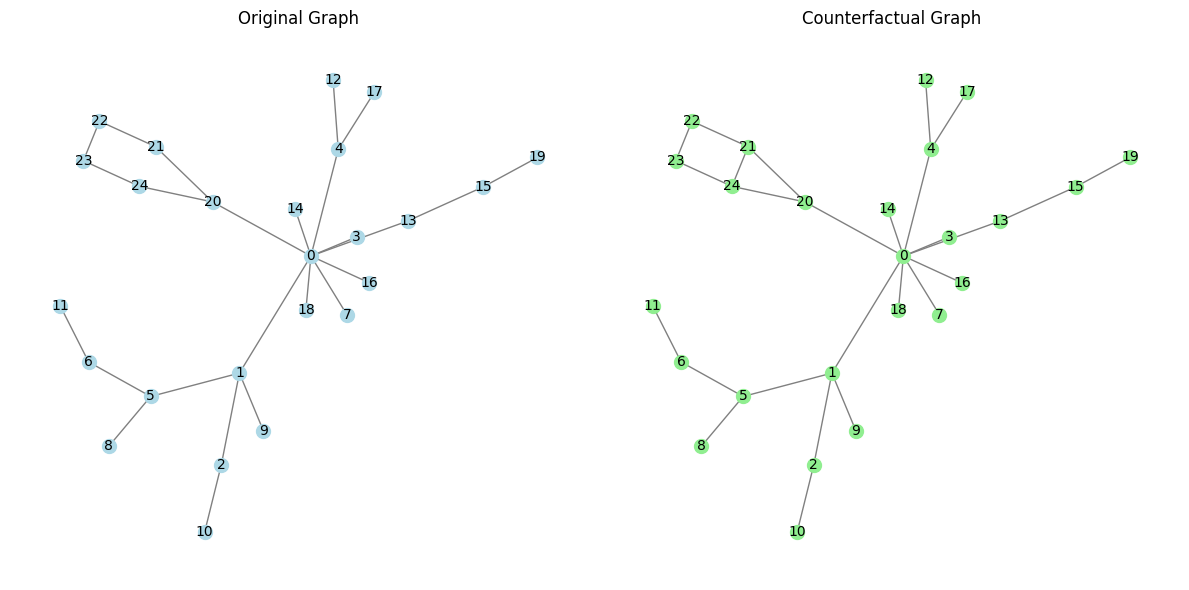

orig y_pred (should be cycle) tensor([[ 3.2812, -2.9644]], grad_fn=<AddmmBackward0>)
cf y_pred (should be house) tensor([[ 0.9347, -0.6115]], grad_fn=<AddmmBackward0>)


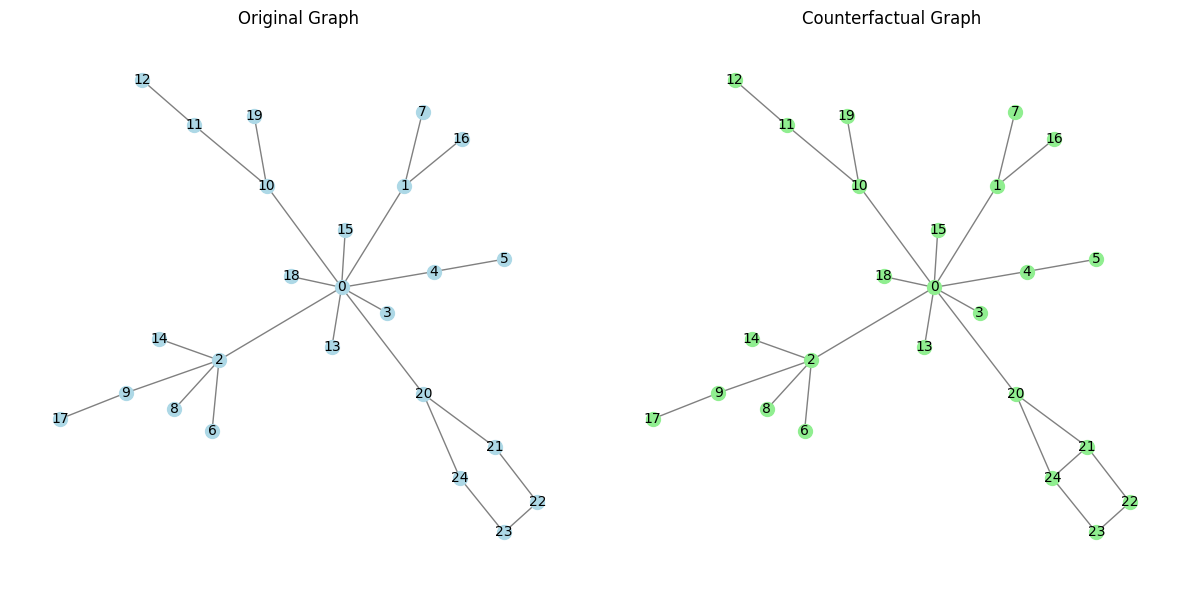

In [29]:
correct = 0
for data in dataset[15]:
    x, edge_index, y, edge_label = data.x, data.edge_index, data.y, data.edge_label

    masked_edge_index = edge_index[:, edge_label.bool()]

    edge_index_adj = to_dense_adj(edge_index, max_num_nodes=25).squeeze()
    masked_edge_index_adj = to_dense_adj(masked_edge_index, max_num_nodes=25).squeeze()

    y_pred = clf_model(x, edge_index)

    print('orig y_pred (should be cycle)', y_pred)

    # Create a new edge tensor
    new_edge = torch.tensor([[21, 24], [24,21]])

    # Concatenate the new edge to the existing edge_index
    edge_index_cf = torch.cat([edge_index, new_edge], dim=1)
    edge_weight_cf = torch.ones(edge_index_cf.size(1))
    edge_weight_cf[-2:] = 2

    y_pred_cf = clf_model(x, edge_index_cf, edge_weights = edge_weight_cf)

    edge_index_cf_adj = to_dense_adj(edge_index_cf, max_num_nodes=25).squeeze()

    print('cf y_pred (should be house)', y_pred_cf)

    visualize_cfs(edge_index_adj, edge_index_cf_adj)
    
    # if y_pred == y.item():
    #     correct += 1

#print(correct/len(dataset))